In [1]:
import os
import glob
import pyspark
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import numpy as np
import random
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta


In [2]:
# Initialize SparkSession
spark = pyspark.sql.SparkSession.builder \
    .appName("dev") \
    .master("local[*]") \
    .getOrCreate()

# Set log level to ERROR to hide warnings
spark.sparkContext.setLogLevel("ERROR")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/24 03:58:40 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
pd.set_option('display.max_columns', None)

In [4]:
df = (spark.read.parquet('datamart/gold/model_monitoring/metrics_*.parquet')
      .toPandas()
      .sort_values('snapshot_date')
      .reset_index(drop = True)
     )

# Performance metrics

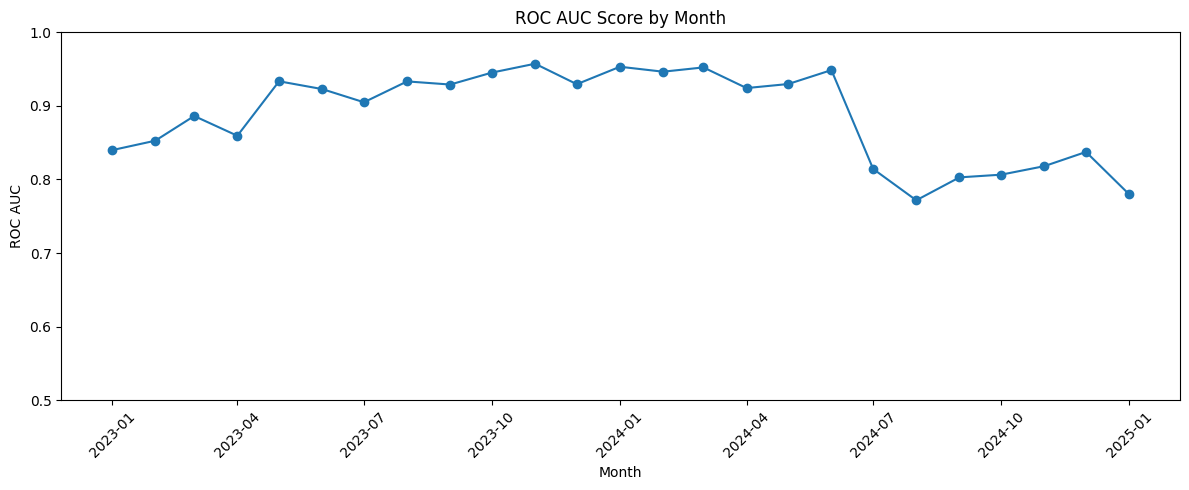

In [5]:
plt.figure(figsize=(12, 5))
plt.plot(df['snapshot_date'], df['roc_auc'], marker='o')
plt.title('ROC AUC Score by Month')
plt.xlabel('Month')
plt.ylabel('ROC AUC')
plt.xticks(rotation=45)
plt.ylim(0.5, 1)
# plt.savefig('ROC_AUC_plot_0.png', bbox_inches='tight', dpi=150)
plt.tight_layout()

# Stability Metrics

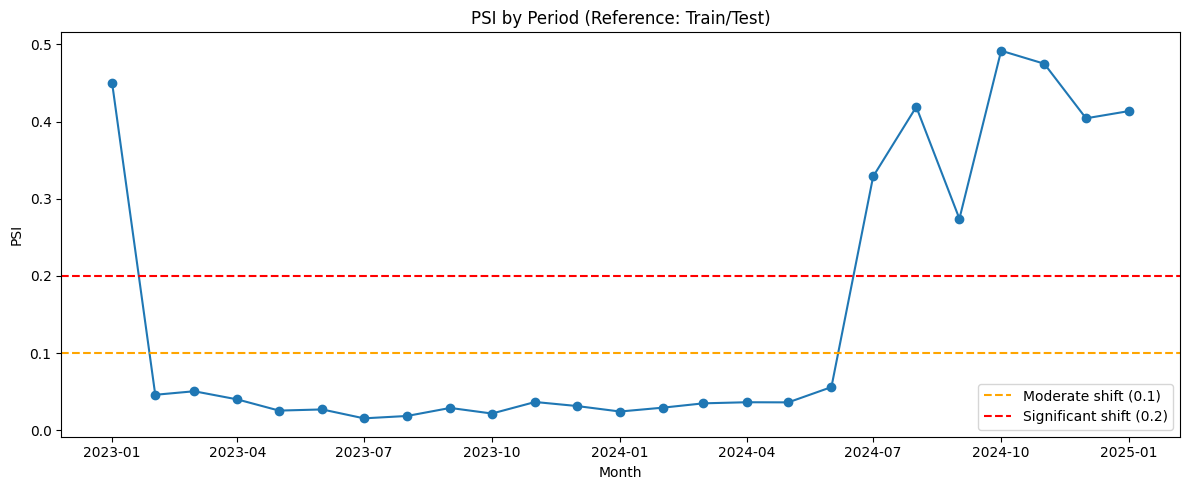

In [6]:
plt.figure(figsize=(12, 5))
plt.plot(df['snapshot_date'], df['psi'], marker='o')
plt.axhline(y=0.1, color='orange', linestyle='--', label='Moderate shift (0.1)')
plt.axhline(y=0.2, color='red', linestyle='--', label='Significant shift (0.2)')
plt.title('PSI by Period (Reference: Train/Test)')
plt.xlabel('Month')
plt.ylabel('PSI')
plt.legend()
# plt.savefig('PSI_plot_0.png', bbox_inches='tight', dpi=150)
plt.tight_layout()

# Investigation

In [7]:
df_feat = spark.read.parquet('datamart/gold/feature_store/gold_joined.parquet').toPandas()

In [8]:
fe_cols = [c for c in df_feat.columns if c.startswith('fe_')]
df_feat.groupby('snapshot_date')[fe_cols].apply(lambda x: x.isna().sum())


,fe_1_mean,fe_2_mean,fe_3_mean,fe_4_mean,fe_5_mean,fe_6_mean,fe_7_mean,fe_8_mean,fe_9_mean,fe_10_mean,fe_11_mean,fe_12_mean,fe_13_mean,fe_14_mean,fe_15_mean,fe_16_mean,fe_17_mean,fe_18_mean,fe_19_mean,fe_20_mean
snapshot_date,,,,,,,,,,,,,,,,,,,,
2023-01-01,530,530,530,530,530,530,530,530,530,530,530,530,530,530,530,530,530,530,530,530
2023-02-01,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2023-03-01,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2023-04-01,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2023-05-01,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2023-06-01,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2023-07-01,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2023-08-01,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2023-09-01,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [9]:
df_feat.groupby('snapshot_date')['has_clickstream'].value_counts().unstack()

has_clickstream,0,1
snapshot_date,,
2023-01-01,530.0,NaN
2023-02-01,NaN,501.0
2023-03-01,NaN,506.0
2023-04-01,NaN,510.0
2023-05-01,NaN,521.0
2023-06-01,NaN,517.0
2023-07-01,NaN,471.0
2023-08-01,NaN,481.0
2023-09-01,NaN,454.0
